In [1]:
# ==========================================
# [CELDA 1] - IMPORTACIÓN DE LIBRERÍAS
# ==========================================
# Instala librerías necesarias si no están en tu entorno.
# Explicación: Importamos herramientas estándar de la industria. No reinventamos la rueda.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import re
import io
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuración visual para plots
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ==========================================
# [CELDA 2] - CARGA DE DATOS EN COLAB
# ==========================================
# Explicación: Usa la interfaz nativa de Colab para subir el archivo.
from google.colab import files

print("Sube tu archivo CSV (ej. 'BASE CLIENTES 01-07-2025 CEDULAS.csv'):")
uploaded = files.upload()

# Tomar el primer archivo subido (asumiendo que es el CSV)
file_name = list(uploaded.keys())[0]

if file_name.endswith('.csv'):
    # sep=None y engine='python' detecta automáticamente si es coma (,) o punto y coma (;)
    df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=None, engine='python', encoding='latin1')
elif file_name.endswith(('.xlsx', '.xls')):
    df_raw = pd.read_excel(io.BytesIO(uploaded[file_name]))
else:
    df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=None, engine='python')

print(f"\nArchivo cargado: {file_name}")



Sube tu archivo CSV (ej. 'BASE CLIENTES 01-07-2025 CEDULAS.csv'):


Saving TODO EL AÑO 2024 am.csv to TODO EL AÑO 2024 am.csv

Archivo cargado: TODO EL AÑO 2024 am.csv


In [3]:
# ==========================================
# [CELDA 3] - EXPLORACIÓN INICIAL (DIAGNÓSTICO)
# ==========================================
# Explicación: Evaluación cruda del estado de los datos. Sin esto, limpiar es ir a ciegas.
def exploracion_inicial(df):
    print("--- SHAPE DEL DATASET ---")
    print(df.shape, "\n")

    print("--- TIPOS DE DATOS Y VALORES NULOS ---")
    print(df.info(), "\n")

    print("--- DUPLICADOS EXACTOS ---")
    print(f"Total duplicados exactos: {df.duplicated().sum()}\n")

    print("--- RESUMEN ESTADÍSTICO (NUMÉRICAS) ---")
    display(df.describe())

    print("--- RESUMEN ESTADÍSTICO (CATEGÓRICAS) ---")
    display(df.describe(include=['object']))

exploracion_inicial(df_raw)


--- SHAPE DEL DATASET ---
(106615, 10) 

--- TIPOS DE DATOS Y VALORES NULOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106615 entries, 0 to 106614
Data columns (total 10 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   CLIENTE                       105909 non-null  object
 1   FECHA                         105909 non-null  object
 2   TIENDA                        105909 non-null  object
 3   CANTIDAD                      105907 non-null  object
 4   DESCRIPCION                   105909 non-null  object
 5   TELEFONO                      105909 non-null  object
 6   PRECIO DE VENTA ANTES DE IVA  105897 non-null  object
 7   MONTO_TOTAL                   106615 non-null  object
 8   CEDULA                        105909 non-null  object
 9   CATEGORIA                     105909 non-null  object
dtypes: object(10)
memory usage: 8.1+ MB
None 

--- DUPLICADOS EXACTOS ---
Total duplicados exactos: 

,CLIENTE,FECHA,TIENDA,CANTIDAD,DESCRIPCION,TELEFONO,PRECIO DE VENTA ANTES DE IVA,MONTO_TOTAL,CEDULA,CATEGORIA
count,105909,105909,105909,105907,105909,105909,105897,106615,105909,105909
unique,20092,362,24,68,4262,19420,659,1877,20615,10
top,Consumidor Final,16/3/2024,Cajero VENTURA,1,[FUN2002] FUNDA NIU HOM POLIETIENO PEQUENA FUN...,099945667,"$0,04","$0,04",9999999999999,MESA
freq,1842,602,20279,85784,8138,340,17818,15499,1857,22829


--- RESUMEN ESTADÍSTICO (CATEGÓRICAS) ---


,CLIENTE,FECHA,TIENDA,CANTIDAD,DESCRIPCION,TELEFONO,PRECIO DE VENTA ANTES DE IVA,MONTO_TOTAL,CEDULA,CATEGORIA
count,105909,105909,105909,105907,105909,105909,105897,106615,105909,105909
unique,20092,362,24,68,4262,19420,659,1877,20615,10
top,Consumidor Final,16/3/2024,Cajero VENTURA,1,[FUN2002] FUNDA NIU HOM POLIETIENO PEQUENA FUN...,099945667,"$0,04","$0,04",9999999999999,MESA
freq,1842,602,20279,85784,8138,340,17818,15499,1857,22829


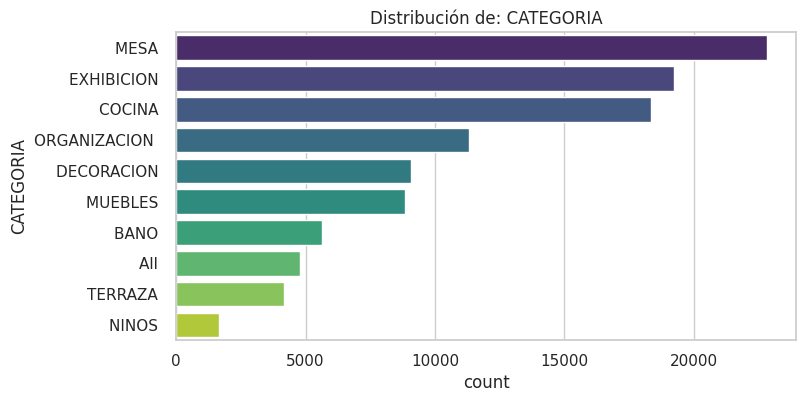

In [4]:
# ==========================================
# [CELDA 4] - VISUALIZACIÓN BÁSICA
# ==========================================
# Explicación: Identifica distribuciones sesgadas y anomalías categóricas de un vistazo.
def visualizar_distribuciones(df):
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = df.select_dtypes(include=['object']).columns

    # Numéricas
    for col in num_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, bins=30, color='blue')
        plt.title(f'Distribución de: {col}')
        plt.show()

    # Categóricas (Top 10 por cardinalidad para evitar gráficos ilegibles)
    for col in cat_cols:
        if df[col].nunique() < 20: # Solo si hay pocas categorías únicas
            plt.figure(figsize=(8, 4))
            sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
            plt.title(f'Distribución de: {col}')
            plt.show()

visualizar_distribuciones(df_raw)



In [5]:
# ==========================================
# [CELDA 5] - FUNCIONES DE LIMPIEZA Y ESTANDARIZACIÓN
# ==========================================
# Explicación: Estandariza columnas, elimina espacios extra, corrige casos y formatos.
def estandarizar_columnas(df):
    # 1. Minúsculas y limpieza de espacios
    df.columns = df.columns.str.strip().str.lower()

    # 2. Mapeo de contingencia para columnas con nombres distintos
    mapeo_columnas = {
        'cliente': 'nombre_del_cliente',
        'precio de venta antes de iva': 'monto_de_facturas',
        'cedula - ruc': 'cedula'
    }
    df.rename(columns=mapeo_columnas, inplace=True)

    # 3. Limpieza final de tildes y formato
    df.columns = (df.columns.str.replace(' ', '_')
                            .str.replace('á', 'a').str.replace('é', 'e').str.replace('í', 'i')
                            .str.replace('ó', 'o').str.replace('ú', 'u')
                            .str.replace('[^a-z0-9_]', '', regex=True))
    return df

def limpiar_formatos(df):
    df = df.copy()

    # 0. Rescate estricto monetario: Forzar a numérico y entender la coma como decimal (ej: " $4,26 ")
    cols_dinero = ['monto_de_facturas', 'monto_total', 'precio_de_venta_antes_de_iva']
    for col in cols_dinero:
        if col in df.columns:
            df[col] = (df[col].astype(str)
                       .str.replace(r'[\$\s]', '', regex=True) # Quita signos $ y espacios vacíos
                       .str.replace(',', '.'))                 # Convierte comas a punto decimal
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 1. Limpieza de strings genérica
    obj_cols = df.select_dtypes(include=['object']).columns
    for col in obj_cols:
        df[col] = df[col].astype(str).str.strip()
        # Forzar nulos reales
        df[col] = df[col].replace(['', 'nan', 'None'], np.nan)

    # 2. Corregir nombres y correos (si existen)
    if 'nombre_del_cliente' in df.columns:
        df['nombre_del_cliente'] = df['nombre_del_cliente'].str.replace('^0', 'O', regex=True).str.title()

    if 'correo_electronico' in df.columns:
        df['correo_electronico'] = df['correo_electronico'].str.lower()
        mask_bad_email = ~df['correo_electronico'].str.contains(r'^[\w\.-]+@[\w\.-]+\.\w+$', na=False)
        df.loc[mask_bad_email, 'correo_electronico'] = np.nan

    # 3. Limpiar teléfonos
    if 'telefono' in df.columns:
        df['telefono'] = df['telefono'].astype(str).str.split('/').str[0].str.replace(r'\D', '', regex=True)
        df['telefono'] = df['telefono'].replace(r'^(.)\1+$', np.nan, regex=True)
        df['telefono'] = df['telefono'].replace('', np.nan)

    # 4. Limpiar cédula (si existe)
    if 'cedula' in df.columns:
        df['cedula'] = df['cedula'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
        df['cedula'] = df['cedula'].replace(['nan', 'None', ''], np.nan)

    return df.drop_duplicates()


In [6]:
# ==========================================
# [CELDA 6] - DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# ==========================================
# Explicación: Uso del rango intercuartílico (IQR) para acotar valores atípicos severos sin eliminar registros.
def tratar_outliers_iqr(df, columnas, factor=1.5):
    df_clean = df.copy()
    for col in columnas:
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            # Evita que el límite inferior sea negativo para variables numéricas (dinero, cantidades)
            limite_inf = max(0, Q1 - (factor * IQR))

            # Capping SOLO inferior. Aplanar hacia arriba destruye valores financieros reales.
            df_clean[col] = np.where(df_clean[col] < limite_inf, limite_inf, df_clean[col])

            # CORRECCIÓN: Redondear a dos decimales de cara a formatos monetarios o exactos
            df_clean[col] = df_clean[col].round(2)

    return df_clean


In [7]:
# ==========================================
# [CELDA 7] - IMPUTACIÓN DE VALORES FALTANTES
# ==========================================
# Explicación: Configurable.
# Numéricos: KNN respeta correlaciones multivariables. Mediana es robusta a sesgos. Media es ingenua.
# Categóricos: "Desconocido" evita inyectar sesgos irreales que la Moda causaría.
def imputar_faltantes(df, estrategia_num='mediana', estrategia_cat='desconocido'):
    df_imp = df.copy()
    num_cols = df_imp.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = df_imp.select_dtypes(include=['object']).columns

    # Imputación Numérica
    if estrategia_num == 'knn':
        imputer = KNNImputer(n_neighbors=5)
        df_imp[num_cols] = imputer.fit_transform(df_imp[num_cols])
        df_imp[num_cols] = df_imp[num_cols].round(2)
    elif estrategia_num == 'mediana':
        df_imp[num_cols] = df_imp[num_cols].fillna(df_imp[num_cols].median().round(2))
    elif estrategia_num == 'media':
        df_imp[num_cols] = df_imp[num_cols].fillna(df_imp[num_cols].mean().round(2))

    # Imputación Categórica
    if estrategia_cat == 'desconocido':
        df_imp[cat_cols] = df_imp[cat_cols].fillna('Desconocido')
    elif estrategia_cat == 'moda':
        for col in cat_cols:
            df_imp[col] = df_imp[col].fillna(df_imp[col].mode()[0])

    return df_imp



In [8]:
# ==========================================
# [CELDA 8] - NORMALIZACIÓN Y DISCRETIZACIÓN
# ==========================================
# Explicación:
# StandardScaler: Centra la media en 0 y desviación en 1. Ideal para PCA, Regresión Logística, SVM.
# MinMaxScaler: Acota entre 0 y 1. Ideal para Redes Neuronales o cuando se requiere evitar valores negativos.
def escalar_datos(df, columnas, metodo='standard'):
    df_scaled = df.copy()
    if metodo == 'standard':
        scaler = StandardScaler()
    elif metodo == 'minmax':
        scaler = MinMaxScaler()
    else:
        return df_scaled

    nuevas_cols = [f"{col}_scaled" for col in columnas]
    df_scaled[nuevas_cols] = scaler.fit_transform(df_scaled[columnas])
    return df_scaled

def discretizar_variable(df, columna, bins=3, etiquetas=None):
    df_disc = df.copy()
    if columna in df_disc.columns:
        if etiquetas is None:
            etiquetas = [f'Nivel_{i+1}' for i in range(bins)]
        nueva_col = f'{columna}_binned'
        df_disc[nueva_col] = pd.cut(df_disc[columna], bins=bins, labels=etiquetas)
    return df_disc


In [9]:
# ==========================================
# [CELDA 8.5] - GENERACIÓN DE ID ÚNICO (CLIENTE_ID)
# ==========================================
# Explicación: Genera un ID basado en la cédula. Si no existe, usa nombre y correo como contingencia.
def generar_id_unico(df):
    df_id = df.copy()

    # Manejar ausencia de correo de manera silenciosa
    correo_str = df_id['correo_electronico'].astype(str) if 'correo_electronico' in df_id.columns else pd.Series([''] * len(df_id), index=df_id.index)
    nombre_str = df_id['nombre_del_cliente'].astype(str) if 'nombre_del_cliente' in df_id.columns else pd.Series([''] * len(df_id), index=df_id.index)

    if 'cedula' in df_id.columns:
        # Base principal: Cédula limpia
        base_hash = df_id['cedula'].astype(str).str.strip().str.lower()

        # Contingencia para cédulas vacías/nulas (fallback a nombre + correo)
        mask_nula = base_hash.isin(['nan', 'desconocido', 'sin registro', 'none', ''])
        if mask_nula.any():
            fallback = nombre_str.loc[mask_nula] + correo_str.loc[mask_nula]
            base_hash.loc[mask_nula] = fallback.str.lower().str.replace(' ', '')
    else:
        # Contingencia total por si falla la columna cédula
        base_hash = nombre_str + correo_str
        base_hash = base_hash.str.lower().str.replace(' ', '')

    # Aplica un hash SHA-256
    df_id['cliente_id'] = base_hash.apply(lambda x: hashlib.sha256(x.encode()).hexdigest()[:10].upper())

    # Reordenar para que cliente_id sea la primera columna
    cols = ['cliente_id'] + [c for c in df_id.columns if c != 'cliente_id']
    return df_id[cols]

In [10]:
# ==========================================
# [CELDA 9] - ANONIMIZACIÓN (PII)
# ==========================================
# Explicación: Protege datos personales (PII). Configurable por método.
def anonimizar_datos(df, columnas, metodo='hash', activar=True):
    if not activar:
        return df

    df_anon = df.copy()
    for col in columnas:
        if col not in df_anon.columns:
            continue

        if metodo == 'hash':
            df_anon[col] = df_anon[col].apply(
                lambda x: hashlib.sha256(str(x).encode()).hexdigest() if str(x) != 'Desconocido' else 'Sin Registro'
            )
        elif metodo == 'enmascarar':
            def enmascarar_valor(x):
                sx = str(x)
                if pd.isna(x) or sx in ['Desconocido', 'nan', '']:
                    return 'Sin Registro'

                if '@' in sx:
                    return re.sub(r'(?<=^.).*(?=@)', '****', sx)
                elif len(sx) > 5:
                    return sx[:3] + '****' + sx[-2:]
                else:
                    return '***'

            df_anon[col] = df_anon[col].apply(enmascarar_valor)
    return df_anon



In [11]:
# ==========================================
# [CELDA 10] - EJECUCIÓN DEL PIPELINE PRINCIPAL
# ==========================================
# Explicación: Orquestación de todas las funciones. Evita código espagueti.
print("\nIniciando Pipeline de Limpieza...\n")

# 1. Estandarizar columnas
df_clean = estandarizar_columnas(df_raw.copy())
print("✓ Columnas estandarizadas.")

# 2. Formatear y deduplicar
df_clean = limpiar_formatos(df_clean)
print("✓ Formatos de strings corregidos y duplicados exactos eliminados.")

# 3. Tratar Outliers (Aplicar a columnas numéricas)
cols_numericas = df_clean.select_dtypes(include=['float64', 'int64']).columns
if len(cols_numericas) > 0:
    df_clean = tratar_outliers_iqr(df_clean, cols_numericas)
    print("✓ Outliers acotados mediante IQR.")
else:
    print("⚠ ADVERTENCIA: No se detectaron columnas numéricas. Revisa los nombres de las columnas.")

# 4. Imputar faltantes
df_clean = imputar_faltantes(df_clean, estrategia_num='mediana', estrategia_cat='desconocido')
print("✓ Valores faltantes imputados.")

# 5. Discretización
if 'monto_de_facturas' in df_clean.columns:
    df_clean = discretizar_variable(df_clean, 'monto_de_facturas', bins=4, etiquetas=['Bajo', 'Medio', 'Alto', 'Muy Alto'])
    print("✓ Variable 'monto_de_facturas' discretizada.")

# 6. Escalamiento
df_clean = escalar_datos(df_clean, cols_numericas, metodo='standard')
print("✓ Variables numéricas escaladas creadas (columna_scaled).")

# 6.5 Generar ID Único
df_clean = generar_id_unico(df_clean)
print("✓ ID único de cliente (Hash basado en Cédula) generado.")

# 7. Anonimización
# Filtro dinámico: Solo anonimiza las columnas PII que realmente existan en el DataFrame
cols_pii_potenciales = ['cedula', 'nombre_del_cliente', 'correo_electronico', 'telefono']
cols_pii = [col for col in cols_pii_potenciales if col in df_clean.columns]

df_clean = anonimizar_datos(df_clean, cols_pii, metodo='enmascarar', activar=True)
print("✓ Datos sensibles anonimizados.")




Iniciando Pipeline de Limpieza...

✓ Columnas estandarizadas.
✓ Formatos de strings corregidos y duplicados exactos eliminados.
✓ Outliers acotados mediante IQR.
✓ Valores faltantes imputados.
✓ Variable 'monto_de_facturas' discretizada.
✓ Variables numéricas escaladas creadas (columna_scaled).
✓ ID único de cliente (Hash basado en Cédula) generado.
✓ Datos sensibles anonimizados.


In [12]:
# ==========================================
# [CELDA 11] - REPORTE FINAL Y EXPORTACIÓN
# ==========================================
def reporte_y_exportacion(df_original, df_final, nombre_salida='dataset_limpio_con_id.csv'):
    print("\n" + "="*40)
    print("REPORTE AUTOMÁTICO DE CALIDAD DE DATOS")
    print("="*40)
    print(f"Filas originales: {df_original.shape[0]} | Filas finales: {df_final.shape[0]}")
    print(f"Duplicados eliminados: {df_original.shape[0] - df_final.shape[0]}")

    nulos_orig = df_original.isna().sum().sum()
    print(f"Valores nulos corregidos: {nulos_orig} -> {df_final.isna().sum().sum()}")

    print("\n[CRÍTICA DE CALIDAD DE DATOS]")
    if nulos_orig > (df_original.shape[0] * df_original.shape[1] * 0.1):
        print("CRÍTICO: Más del 10% de tu dataset era nulo. Revisa los procesos de recolección en origen.")
    if (df_original.shape[0] - df_final.shape[0]) > 0:
        print("ADVERTENCIA: Existían filas duplicadas. Implementa llaves primarias estrictas en la base de datos.")

    # Exportación
    df_final.to_csv(nombre_salida, index=False)
    print(f"\nArchivo guardado exitosamente como: {nombre_salida}")

    # Descargar en Google Colab
    try:
        files.download(nombre_salida)
        print("Descarga iniciada...")
    except Exception as e:
        print("Error al descargar (asegúrate de ejecutar esto en Colab).")

reporte_y_exportacion(df_raw, df_clean)
display(df_clean.head())


REPORTE AUTOMÁTICO DE CALIDAD DE DATOS
Filas originales: 106615 | Filas finales: 100941
Duplicados eliminados: 5674
Valores nulos corregidos: 6368 -> 0

[CRÍTICA DE CALIDAD DE DATOS]
ADVERTENCIA: Existían filas duplicadas. Implementa llaves primarias estrictas en la base de datos.

Archivo guardado exitosamente como: dataset_limpio_con_id.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada...


,cliente_id,nombre_del_cliente,fecha,tienda,cantidad,descripcion,telefono,monto_de_facturas,monto_total,cedula,categoria,monto_de_facturas_binned,monto_de_facturas_scaled,monto_total_scaled
0,C69E2886A2,Mir****lo,2/1/2024,Cajero Loja,1,[X14-N20-19-G/1] TABURETE MAYA TERCIOPELO GRIS...,099****04,78.50,78.50,110****88,MUEBLES,Bajo,1.382177,1.002468
1,595C7B9F52,Nor****do,2/1/2024,Cajero Loja,3,[770506] PLATO TENDIDO MELAMINE AZUL 770506 (2...,099****27,3.48,10.45,110****94,MESA,Bajo,-0.328936,-0.227924
2,595C7B9F52,Nor****do,2/1/2024,Cajero Loja,3,[730817] PLATO TENDIDO MELAMINE AZUL 730817 (2...,099****27,4.38,13.13,110****94,MESA,Bajo,-0.308408,-0.179468
3,595C7B9F52,Nor****do,2/1/2024,Cajero Loja,1,[FUN2001] FUNDA NIU HOM POLIETIENO MEDIANA FUN...,099****27,0.04,0.04,110****94,EXHIBICION,Bajo,-0.407398,-0.416144
4,C36D02810B,Vic****ho,2/1/2024,On line LOJA,1,[LWM0940-7-B-NG] ESPEJO MOD. ARCO MARCO DE ALU...,099****30,53.48,53.48,110****03,BANO,Bajo,0.811502,0.550089
